In [2]:
import numpy as np
import matplotlib.pyplot as plt
#import pandas as pd

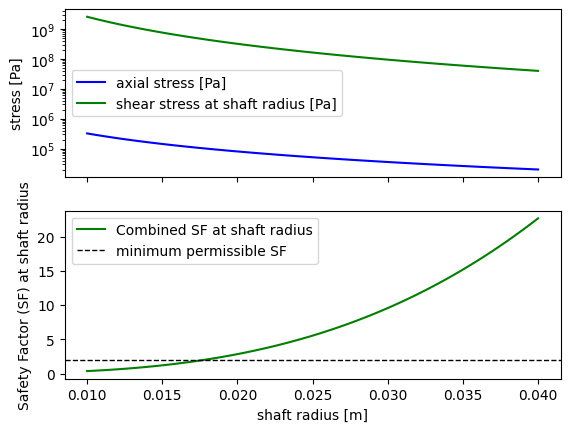

(3847162.2576624015,
 3988.891792726691,
 101.72591120000004,
 array([7842.43020421, 7614.009907  , 7398.51906057, 7194.8900956 ,
        7002.16982518, 6819.5045254 , 6646.1272917 , 6481.3472762 ,
        6324.54048726, 6175.14189308, 6032.63861862, 5896.56406331,
        5766.49279721, 5642.03611813, 5522.83817198, 5408.57255463,
        5298.93932717, 5193.66238689, 5092.48714559, 4995.17847402,
        4901.51887763, 4811.30687375, 4724.3555447 , 4640.49124509,
        4559.55244431, 4481.38868812, 4405.85966528, 4332.83436697,
        4262.19032837, 4193.81294343, 4127.59484432, 4063.43533897,
        4001.23990011, 3940.91970061, 3882.3911902 , 3825.57570937,
        3770.39913664, 3716.79156597, 3664.68701131, 3614.02313558,
        3564.74100191, 3516.78484494, 3470.10186027, 3424.64201057,
        3380.35784664, 3337.20434222, 3295.13874126, 3254.12041668,
        3214.11073943, 3175.07295717, 3136.97208168, 3099.77478427,
        3063.44929852, 3027.96532981, 2993.29397107, 2

In [22]:
#LP SHAFT RADIUS
#axial force = mdot * delta(axial velocity)
#tangential force = 

mdot_air_45 = 24.340     #[kg s^-1]
mdot_air_5 = 25.067     #[kg s^-1]
cp = 1212               #[J K^-1]

T_0_45 = 1829.12        # TET [K]
T_0_5 = 1630.52        # Turbine exit Temperature [K]
omega_LPT = 9210 * np.pi/30  #angular velocity [rad s^-1]
efficiency_to_shaft = 0.87      #empirical value from propulsion notes

W_sh = efficiency_to_shaft*cp*(mdot_air_45*T_0_45 - mdot_air_5*T_0_5)         #shaft power [W]

Torque = W_sh/omega_LPT         #[N m]

V_x = 139.9256
theta_41 = 49.23 * np.pi/180        # [rad]
theta_44 = -2.72 * np.pi/180        # [rad]

F_n = -V_x*(mdot_air_45-mdot_air_5)    #Positive in rightward direction

#STRESSES
R_ii = np.linspace(0.01, 0.04, 101)


tau = 2*Torque/(np.pi*R_ii**3)       #shear stress [Pa]
sigma_x = F_n/(np.pi*R_ii**2)        #axial stress [Pa]
sigma_y = 1800e6                  #yield stress [Pa]

SF_shaft = sigma_y/np.sqrt(sigma_x**2 + 4*tau**2)
permissible_SF = 2

#plotting

fig, (ax_stress, ax_SF_shaft) = plt.subplots(2, 1, sharex=True)


ax_SF_shaft.plot(R_ii, SF_shaft, color='green', label='Combined SF at shaft radius')
ax_SF_shaft.set_xlabel('shaft radius [m]')
ax_SF_shaft.set_ylabel('Safety Factor (SF) at shaft radius')
ax_SF_shaft.axhline(y=permissible_SF, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF_shaft.legend()

ax_stress.plot(R_ii, sigma_x, color='blue', label='axial stress [Pa]')
ax_stress.plot(R_ii, tau, color='green', label='shear stress at shaft radius [Pa]')
ax_stress.set_ylabel('stress [Pa]')
ax_stress.set_yscale('log')
ax_stress.legend()

plt.show()

R_ii = R_ii[SF_shaft >= permissible_SF][0]        #returns shaft radius for which safety factor is 2

W_sh, Torque, F_n, tau/sigma_x, R_ii

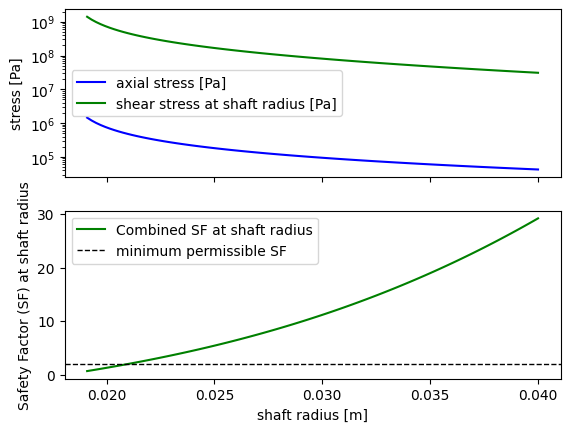

(5436767.4386688005,
 2969.706774183726,
 169.4499015999998,
 array([966.86537547, 966.24319672, 965.51605963, 964.68779493,
        963.76213404, 962.7427102 , 961.63305962, 960.43662285,
        959.15674611, 957.79668273, 956.35959469, 954.84855414,
        953.26654505, 951.61646479, 949.90112587, 948.12325759,
        946.28550777, 944.39044447, 942.44055777, 940.43826146,
        938.38589483, 936.28572441, 934.13994565, 931.95068475,
        929.72000028, 927.44988493, 925.14226719, 922.799013  ,
        920.42192742, 918.01275622, 915.57318751, 913.10485329,
        910.60933103, 908.08814514, 905.54276852, 902.97462397,
        900.38508569, 897.77548061, 895.14708984, 892.50114998,
        889.83885443, 887.1613547 , 884.46976167, 881.7651468 ,
        879.04854331, 876.32094741, 873.58331938, 870.83658473,
        868.08163521, 865.31932994, 862.5504964 , 859.77593142,
        856.99640218, 854.21264709, 851.42537681, 848.63527505,
        845.84299947, 843.04918253, 840.254

In [23]:
#HP SHAFT RADIUS
#axial force = mdot * delta(axial velocity)
#tangential force = 

mdot_air_41 = 23.129     #[kg s^-1]
mdot_air_44 = 24.340     #[kg s^-1]
cp = 1248               #[J K^-1]

T_0_41 = 2129.62        # TET [K]
T_0_44 = 1829.12        # Turbine exit Temperature [K]
omega_HPT = 17482.3 * np.pi/30  #angular velocity [rad s^-1]
efficiency_to_shaft = 0.92      #empirical value from propulsion notes

W_sh = efficiency_to_shaft*cp*(mdot_air_41*T_0_41 - mdot_air_44*T_0_44)         #shaft power [W]

Torque = W_sh/omega_HPT         #[N m]

V_x = 139.9256
theta_41 = 42.84 * np.pi/180        # [rad]
theta_44 = 10.42 * np.pi/180        # [rad]

F_n = -V_x*(mdot_air_41-mdot_air_44)    #Positive in rightward direction

#STRESSES
R_i = np.linspace(R_ii+0.001, 0.04, 101)

Area = np.pi*(R_i**2 - R_ii**2)
J = 0.5*np.pi*(R_i**4 - R_ii**4)

tau = Torque*R_i/J       #shear stress [Pa]
sigma_x = F_n/Area        #axial stress [Pa]
sigma_y = 1800e6                  #yield stress [Pa]

SF_shaft = sigma_y/np.sqrt(sigma_x**2 + 4*tau**2)
permissible_SF = 2

#plotting

fig, (ax_stress, ax_SF_shaft) = plt.subplots(2, 1, sharex=True)


ax_SF_shaft.plot(R_i, SF_shaft, color='green', label='Combined SF at shaft radius')
ax_SF_shaft.set_xlabel('shaft radius [m]')
ax_SF_shaft.set_ylabel('Safety Factor (SF) at shaft radius')
ax_SF_shaft.axhline(y=permissible_SF, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF_shaft.legend()

ax_stress.plot(R_i, sigma_x, color='blue', label='axial stress [Pa]')
ax_stress.plot(R_i, tau, color='green', label='shear stress at shaft radius [Pa]')
ax_stress.set_ylabel('stress [Pa]')
ax_stress.set_yscale('log')
ax_stress.legend()

plt.show()

R_i = R_i[SF_shaft >= permissible_SF][0]        #returns shaft radius for which safety factor is 2

W_sh, Torque, F_n, tau/sigma_x, R_i

In [5]:
#HARDCODED VARIABLES

t = 0.5        #disc thickness [m]
T_g = 2193.28    #Gas temperature [K]
T_c = 752.86     #cooling air temperature [K]
eps = 0.788    #cooling constant [1]
rho_disc = 8220.9317    #disc density [kg m^-3]
rho_blade = 8220.9317   #blade density [kg m^-3]
R_m = 0.170          #mean radius of blade [m]

h_blade = 0.0378      #blade height [m]
t_blade = 0.0042      #blade thickness [m]
c_blade = 0.02819      #blade chord length [m]
N_b = 38          #number of blades [1]
nu = 0.313          #inconel 718 poisson ratio [1]

R_o = R_m - 0.5*h_blade          #outer radius of disc [m]

R_o, omega_HPT

(0.1511, 1830.742174928428)

In [6]:
#INTERMEDIATE VARIABLES

F_rim = rho_blade * h_blade*t_blade*c_blade * R_m * omega_HPT**2
T_m = T_g - eps*(T_g-T_c)

In [7]:
F_rim, T_m

(20963.341085488053, 1058.2290400000002)

In [8]:
r = np.linspace(R_i, R_o, 101)    #radius for plotting stresses [m]
r

array([0.0262  , 0.027449, 0.028698, 0.029947, 0.031196, 0.032445,
       0.033694, 0.034943, 0.036192, 0.037441, 0.03869 , 0.039939,
       0.041188, 0.042437, 0.043686, 0.044935, 0.046184, 0.047433,
       0.048682, 0.049931, 0.05118 , 0.052429, 0.053678, 0.054927,
       0.056176, 0.057425, 0.058674, 0.059923, 0.061172, 0.062421,
       0.06367 , 0.064919, 0.066168, 0.067417, 0.068666, 0.069915,
       0.071164, 0.072413, 0.073662, 0.074911, 0.07616 , 0.077409,
       0.078658, 0.079907, 0.081156, 0.082405, 0.083654, 0.084903,
       0.086152, 0.087401, 0.08865 , 0.089899, 0.091148, 0.092397,
       0.093646, 0.094895, 0.096144, 0.097393, 0.098642, 0.099891,
       0.10114 , 0.102389, 0.103638, 0.104887, 0.106136, 0.107385,
       0.108634, 0.109883, 0.111132, 0.112381, 0.11363 , 0.114879,
       0.116128, 0.117377, 0.118626, 0.119875, 0.121124, 0.122373,
       0.123622, 0.124871, 0.12612 , 0.127369, 0.128618, 0.129867,
       0.131116, 0.132365, 0.133614, 0.134863, 0.136112, 0.137

In [9]:
A = (3 + nu)*rho_disc*omega_HPT**2/8
A

11410557452.82063

In [10]:
B = (N_b*F_rim*R_o)/(2*np.pi*t*(R_o**2-R_i**2))
B

np.float64(1730164.9704883394)

In [11]:
C = (1+3*nu)/(3+nu)
C

0.5852701479022034

In [12]:
sigma_r = A*(R_i**2 + R_o**2 - (R_i**2 * R_o**2/r**2) - r**2) + B*(1 - (R_i/r)**2)
sigma_theta = A*(R_i**2 + R_o**2 + (R_i**2 * R_o**2/r**2) - C*r**2) + B*(1 + (R_i/r)**2)
sigma_p = np.max([sigma_r, sigma_theta], axis=0)
SF = sigma_y * 1/sigma_p
SF

array([0.93520999, 0.97932009, 1.02150569, 1.061814  , 1.10030756,
       1.1370599 , 1.17215194, 1.20566912, 1.23769919, 1.2683304 ,
       1.29765019, 1.32574418, 1.3526955 , 1.37858423, 1.4034871 ,
       1.42747733, 1.4506245 , 1.47299458, 1.49464998, 1.51564963,
       1.53604915, 1.55590097, 1.5752545 , 1.59415631, 1.6126503 ,
       1.63077788, 1.64857811, 1.66608792, 1.68334224, 1.70037413,
       1.71721496, 1.73389456, 1.75044129, 1.76688223, 1.78324328,
       1.79954922, 1.81582389, 1.83209024, 1.84837044, 1.86468595,
       1.88105764, 1.89750581, 1.91405033, 1.93071065, 1.94750594,
       1.96445507, 1.98157675, 1.99888954, 2.01641194, 2.03416241,
       2.0521595 , 2.07042183, 2.08896817, 2.10781752, 2.12698915,
       2.14650266, 2.16637801, 2.18663564, 2.20729646, 2.22838197,
       2.2499143 , 2.27191627, 2.29441149, 2.31742438, 2.34098033,
       2.36510569, 2.38982794, 2.41517571, 2.44117895, 2.46786899,
       2.49527866, 2.52344241, 2.55239648, 2.58217899, 2.61283

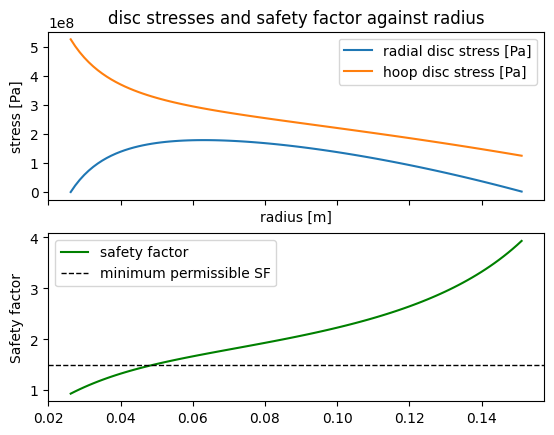

In [13]:
fig, (ax_sigma, ax_SF) = plt.subplots(2, 1, sharex=True)

ax_sigma.set_title('disc stresses and safety factor against radius')
ax_sigma.set_xlabel('radius [m]')
ax_sigma.set_ylabel('stress [Pa]')
ax_sigma.plot(r, sigma_r, label='radial disc stress [Pa]')
ax_sigma.plot(r, sigma_theta, label='hoop disc stress [Pa]')


ax_SF.set_ylabel('Safety factor')
ax_SF.plot(r, SF, label='safety factor', color='green')
ax_SF.axhline(y=1.5, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF.legend()

ax_sigma.legend()

plt.savefig('disc_stress_and_SF.png')

In [14]:
#CONSTANT STRESS
SF_constant = 1.5
sigma_p = sigma_y/SF_constant
sigma_p

329033333.3333333

In [15]:
B = rho_disc*omega_HPT**2/(2*sigma_p)
#h_0 = F_rim/(2*sigma_p*np.pi*R_o)
h_0 = 0.0252        #axial chord [m]
B, h_0

(41.8702467486622, 0.0252)

In [16]:
h = h_0*np.exp(B*(R_o**2-r**2))
h

array([0.06369149, 0.06351305, 0.06332683, 0.06313291, 0.06293136,
       0.06272227, 0.0625057 , 0.06228174, 0.06205048, 0.061812  ,
       0.06156639, 0.06131375, 0.06105417, 0.06078775, 0.06051459,
       0.06023478, 0.05994843, 0.05965566, 0.05935655, 0.05905124,
       0.05873982, 0.0584224 , 0.05809912, 0.05777007, 0.05743539,
       0.05709518, 0.05674958, 0.0563987 , 0.05604267, 0.05568161,
       0.05531565, 0.05494492, 0.05456954, 0.05418965, 0.05380537,
       0.05341684, 0.05302419, 0.05262755, 0.05222705, 0.05182284,
       0.05141503, 0.05100377, 0.05058918, 0.05017142, 0.0497506 ,
       0.04932687, 0.04890036, 0.0484712 , 0.04803954, 0.0476055 ,
       0.04716922, 0.04673083, 0.04629047, 0.04584827, 0.04540436,
       0.04495888, 0.04451195, 0.04406371, 0.04361428, 0.0431638 ,
       0.04271239, 0.04226018, 0.0418073 , 0.04135387, 0.04090001,
       0.04044585, 0.03999151, 0.0395371 , 0.03908276, 0.03862859,
       0.0381747 , 0.03772123, 0.03726827, 0.03681594, 0.03636

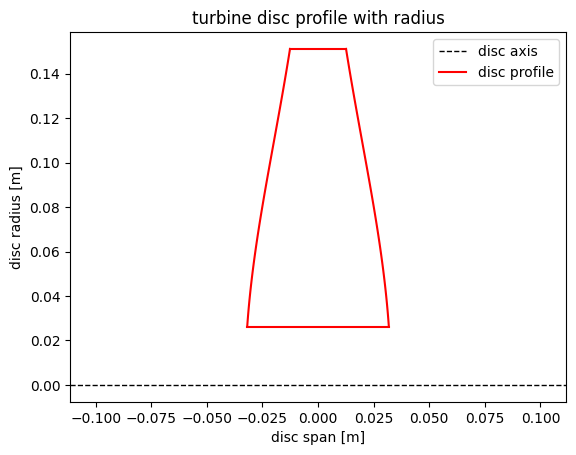

In [17]:
#PLOT DISC PROFILE

h_positive = h/2
h_negative = -h_positive

h_o = h[-1]
h_i = h[0]



fig, ax = plt.subplots()
ax.plot([-h_i/2, h_i/2], [R_i, R_i], color='red')
ax.plot([-h_o/2, h_o/2], [R_o, R_o], color='red')

ax.axhline(y=0, color='black', linestyle='dashed', linewidth=1, label='disc axis')

ax.plot(h_positive, r, color='red', label='disc profile')
ax.plot(h_negative, r, color='red')
ax.axis('equal')

#Title and axis labels and other silly things
ax.set_title('turbine disc profile with radius')
ax.set_xlabel('disc span [m]')
ax.set_ylabel('disc radius [m]')
ax.legend()

plt.savefig('disc_profile.png')